### Synthetic Data Generation 

This script generate synthetic datapoints aiding the development of the analysis pipline. While shape and form are similiar to real world data this dataset is never to be used for real anlayisi purposes. 

Data generate from this script will always be labeled with the suffix `_syn`



## Data Structure

| Column name | Data type | Scale / role | Cardinality | Valid range / format |
|---|---|---|---:|---|
| `Sparte_ID` | `int` | Categorical (nominal identifier) | 7 | 1–7 |
| `Sparte_Text` | `str` | Categorical (nominal label) | 7 | — |
| `Fachgruppe_ID` | `str` | Categorical (nominal identifier) | 95 | Values parsed from the 2025 Fachorganisation reference CSV |
| `Fachgruppe_Text` | `str` | Categorical (nominal label) | 95 | Labels from the 2025 Fachorganisation reference CSV |
| `Mitglied_Gründungsdatum` | `datetime64[ns]` | Temporal (date) | — | Valid date or missing value |
| `Standort_Angelegt` | `datetime64[ns]` | Temporal (date) | — | Valid date or missing value |
| `Standort_Gelöscht` | `datetime64[ns]` | Temporal (date) | — | Valid date or missing value |
| `Mitglied_Löschdatum` | `datetime64[ns]` | Temporal (date) | — | Valid date or missing value |
| `OSM_Building_ID` | `str` | OSM source building identifier | High | ID from the local Geofabrik extract |
| `OSM_Building_Type` | `str` | OSM building classification | Medium | Value of the OSM `building` tag |
| `X_Koordinate` | `float` | Easting (continuous spatial coordinate) | High | EPSG:3035, metres |
| `Y_Koordinate` | `float` | Northing (continuous spatial coordinate) | High | EPSG:3035, metres |
| `geometry` | `geometry` (`Point`) | Spatial point geometry | High | `POINT (X Y)`, EPSG:3035 |

> The synthetic dataset uses **ETRS89 / LAEA Europe (EPSG:3035)** to match the population-grid data used elsewhere in this project. Therefore, `X_Koordinate` is the **easting** and `Y_Koordinate` is the **northing**, both measured in metres.


## Setup

The generator uses established Python packages rather than implementing geospatial operations from scratch:

- **NumPy** generates reproducible, left-skewed synthetic founding dates.
- **GeoPandas/Pyogrio** read the Styrian municipality boundaries and OSM building footprints.
- **Shapely** represents and validates point geometries.
- **NumPy/Pandas** generate categorical values and enforce temporal consistency.

Run the following cell once if these packages are not installed in the active notebook environment.


In [1]:
%pip install pandas geopandas pyogrio shapely pyarrow matplotlib tqdm


Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyogrio
from tqdm.auto import tqdm

RANDOM_SEED = 42
N_ROWS = 10_000
CRS = "EPSG:3035"
AS_OF_DATE = pd.Timestamp("2025-12-31")

# This works when the notebook is started from either the repository root or SDG/.
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "OGD").exists() and (PROJECT_DIR.parent / "OGD").exists():
    PROJECT_DIR = PROJECT_DIR.parent

BOUNDARY_PATH = PROJECT_DIR / "OGD" / "Gemeindegrenzen.zip"
FACHGRUPPEN_PATH = PROJECT_DIR / "SDG" / "fachorganisationen_total_members.csv"
OSM_PBF_PATH = PROJECT_DIR / "OGD" / "OpenStreetMap" / "austria-2025.osm.pbf"
OUTPUT_PATH = PROJECT_DIR / "SDG" / "companies_styria_syn.geoparquet"

if not BOUNDARY_PATH.exists():
    raise FileNotFoundError(f"Styrian municipality boundaries not found: {BOUNDARY_PATH}")
if not FACHGRUPPEN_PATH.exists():
    raise FileNotFoundError(f"Fachgruppe reference data not found: {FACHGRUPPEN_PATH}")
if not OSM_PBF_PATH.exists():
    raise FileNotFoundError(
        "OSM extract not found. Download https://download.geofabrik.de/europe/"
        f"an Austria OSM PBF snapshot and save it as: {OSM_PBF_PATH}"
    )


c:\Users\leopo\Documents\CO2_Master_Code\CO2_Masterarbeit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generator

The seven divisions and 95 Fachgruppen are read from `fachorganisationen_total_members.csv`. `Fachgruppe_ID` is parsed from the part before ` - ` in the `fachgruppe` column, while `Fachgruppe_Text` contains the remaining label. The 2025 `sum_total_members` values are normalized into sampling probabilities, so the synthetic category distribution follows the supplied membership distribution.

Every reference Fachgruppe is included at least once. The remaining observations are sampled with replacement using the 2025 member weights. This makes all valid categories available in a 10,000-row development dataset while keeping its overall distribution close to the source.

Company locations are sampled from real OpenStreetMap building footprints in Styria. Clearly non-occupiable auxiliary structures such as sheds, garages, roofs, and barns are excluded. Sampling combines a square-root footprint-area weight with a building-type factor: commercial, office, retail, industrial, and warehouse buildings are favored; residential buildings are less likely; and single-family houses have the lowest—but still non-zero—probability. Each generated point is the building's representative point, which is guaranteed to lie inside its footprint. Multiple companies may share a building.

Dates obey the following rules:

- founding dates range from 1900 through the as-of date and follow a left-skewed calendar-date distribution, so recent dates are common while old dates form a long tail;
- a location cannot be created before its membership is founded;
- a location cannot be deleted before it is created;
- a membership deletion cannot precede its location deletion;
- active records contain missing deletion dates.


In [3]:
SPARTEN = {
    1: "Gewerbe und Handwerk",
    2: "Industrie",
    3: "Handel",
    4: "Bank und Versicherung",
    5: "Transport und Verkehr",
    6: "Tourismus und Freizeitwirtschaft",
    7: "Information und Consulting",
}

NON_OCCUPIABLE_BUILDING_TYPES = {
    "barn",
    "carport",
    "farm_auxiliary",
    "garage",
    "garages",
    "greenhouse",
    "roof",
    "shed",
    "stable",
}

# Relative likelihood that a company occupies each OSM building type.
# Unlisted occupiable types retain a non-zero neutral weight of 1.0.
BUILDING_TYPE_FACTORS = {
    "commercial": 4.0,
    "office": 4.0,
    "retail": 3.5,
    "industrial": 3.0,
    "warehouse": 2.5,
    "hotel": 2.5,
    "supermarket": 2.5,
    "kiosk": 2.0,
    "civic": 1.5,
    "public": 1.5,
    "mixed_use": 1.5,
    "apartments": 0.8,
    "residential": 0.6,
    "terrace": 0.5,
    "house": 0.25,
    "detached": 0.20,
    "bungalow": 0.20,
}


def read_styria_boundary(boundary_path: Path, target_crs: str = CRS):
    """Read and dissolve the Styrian municipality polygons."""
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message=".*FLAECHE_HA parsed incompletely.*")
        municipalities = gpd.read_file(
            boundary_path,
            layer="Gemeindegrenzen",
            columns=["GEMNR"],
        )

    municipalities = municipalities.to_crs(target_crs)
    if hasattr(municipalities.geometry, "union_all"):
        boundary = municipalities.geometry.union_all()
    else:
        boundary = municipalities.geometry.unary_union

    return municipalities, boundary


def read_osm_buildings(
    osm_pbf_path: Path,
    boundary,
    target_crs: str = CRS,
) -> gpd.GeoDataFrame:
    """Read OSM building footprints in Styria from a local Geofabrik PBF."""
    layer_names = set(pyogrio.list_layers(osm_pbf_path)[:, 0])
    if "multipolygons" not in layer_names:
        raise ValueError(
            f"The OSM extract has no 'multipolygons' layer: {osm_pbf_path}"
        )

    # The OSM PBF uses WGS84. Restricting the read to Styria avoids loading Austria.
    boundary_wgs84 = gpd.GeoSeries([boundary], crs=target_crs).to_crs("EPSG:4326")
    bbox = tuple(boundary_wgs84.total_bounds)
    buildings = gpd.read_file(
        osm_pbf_path,
        layer="multipolygons",
        bbox=bbox,
        where="building IS NOT NULL",
        engine="pyogrio",
    )

    if "building" not in buildings.columns:
        raise ValueError("The OSM multipolygons layer does not expose a building tag")

    buildings = buildings.loc[
        buildings["building"].notna()
        & ~buildings["building"].astype("string").str.lower().isin(
            NON_OCCUPIABLE_BUILDING_TYPES
        )
        & buildings.geometry.notna()
        & ~buildings.geometry.is_empty
        & buildings.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
    ].to_crs(target_crs)

    # Retain only footprints whose internal representative point lies in Styria.
    building_points = buildings.geometry.representative_point()
    buildings = buildings.loc[building_points.within(boundary)].copy()
    if buildings.empty:
        raise ValueError("No OSM building footprints were found inside Styria")

    id_candidates = [column for column in ("osm_way_id", "osm_id") if column in buildings]
    if not id_candidates:
        raise ValueError("The OSM buildings have no osm_way_id or osm_id column")

    building_ids = buildings[id_candidates[0]].astype("string")
    for column in id_candidates[1:]:
        building_ids = building_ids.fillna(buildings[column].astype("string"))

    buildings["OSM_Building_ID"] = building_ids
    buildings = buildings.loc[buildings["OSM_Building_ID"].notna()].copy()
    buildings["OSM_Building_Type"] = buildings["building"].astype("string")
    normalized_types = buildings["OSM_Building_Type"].str.lower()
    type_factors = normalized_types.map(BUILDING_TYPE_FACTORS).fillna(1.0)
    area_factors = np.sqrt(buildings.geometry.area.clip(lower=20, upper=5_000))
    buildings["Sampling_Gewicht"] = area_factors * type_factors
    buildings["Sampling_Gewicht"] /= buildings["Sampling_Gewicht"].sum()

    return buildings[
        ["OSM_Building_ID", "OSM_Building_Type", "Sampling_Gewicht", "geometry"]
    ].reset_index(drop=True)


def sample_company_buildings(
    buildings: gpd.GeoDataFrame,
    count: int,
    rng: np.random.Generator,
) -> gpd.GeoDataFrame:
    """Sample buildings with replacement and return one internal point per company."""
    selected_indices = rng.choice(
        len(buildings),
        size=count,
        replace=True,
        p=buildings["Sampling_Gewicht"].to_numpy(),
    )
    selected = buildings.iloc[selected_indices].reset_index(drop=True).copy()
    selected.geometry = selected.geometry.representative_point()
    return selected


def random_date_between(
    start: pd.Timestamp,
    end: pd.Timestamp,
    rng: np.random.Generator,
) -> pd.Timestamp:
    """Return a random date in the inclusive interval [start, end]."""
    start = pd.Timestamp(start).normalize()
    end = pd.Timestamp(end).normalize()
    days = (end - start).days
    return start + pd.Timedelta(days=int(rng.integers(0, days + 1)))


def sample_left_skewed_dates(
    start: pd.Timestamp,
    end: pd.Timestamp,
    count: int,
    rng: np.random.Generator,
) -> pd.DatetimeIndex:
    """Sample dates with a recent-date peak and a long tail toward older dates."""
    start = pd.Timestamp(start).normalize()
    end = pd.Timestamp(end).normalize()
    if end < start:
        raise ValueError("end must not be earlier than start")

    # Beta(5, 2) is negatively/left skewed on the calendar-date axis.
    fractions = rng.beta(5.0, 2.0, size=count)
    day_offsets = np.rint(fractions * (end - start).days).astype(int)
    return pd.DatetimeIndex(start + pd.to_timedelta(day_offsets, unit="D"))


def load_fachgruppen(reference_path: Path) -> pd.DataFrame:
    """Load Fachgruppen and derive IDs, labels, Sparte IDs, and 2025 weights."""
    reference = pd.read_csv(reference_path, encoding="utf-8-sig")
    required_columns = {"sparte", "fachgruppe", "sum_total_members"}
    missing_columns = required_columns.difference(reference.columns)
    if missing_columns:
        raise ValueError(f"Missing Fachgruppe columns: {sorted(missing_columns)}")

    parsed = reference["fachgruppe"].str.extract(
        r"^\s*(?P<Fachgruppe_ID>[^-]+?)\s*-\s*(?P<Fachgruppe_Text>.+?)\s*$"
    )
    if parsed.isna().any().any():
        invalid = reference.loc[parsed.isna().any(axis=1), "fachgruppe"].tolist()
        raise ValueError(f"Could not parse Fachgruppe ID and label: {invalid}")

    sparte_to_id = {name: identifier for identifier, name in SPARTEN.items()}
    unknown_sparten = sorted(set(reference["sparte"]) - set(sparte_to_id))
    if unknown_sparten:
        raise ValueError(f"Unknown Sparte labels: {unknown_sparten}")

    fachgruppen = parsed.assign(
        Sparte_ID=reference["sparte"].map(sparte_to_id).astype("int64"),
        Sparte_Text=reference["sparte"].str.strip(),
        Mitglieder_2025=pd.to_numeric(reference["sum_total_members"], errors="raise"),
    )

    if fachgruppen["Fachgruppe_ID"].duplicated().any():
        duplicates = fachgruppen.loc[
            fachgruppen["Fachgruppe_ID"].duplicated(keep=False), "Fachgruppe_ID"
        ].tolist()
        raise ValueError(f"Duplicate Fachgruppe IDs: {duplicates}")
    if fachgruppen["Mitglieder_2025"].le(0).any():
        raise ValueError("All 2025 membership counts must be positive")

    fachgruppen["Sampling_Gewicht"] = (
        fachgruppen["Mitglieder_2025"] / fachgruppen["Mitglieder_2025"].sum()
    )
    return fachgruppen.reset_index(drop=True)


def generate_synthetic_companies(
    count: int,
    buildings: gpd.GeoDataFrame,
    fachgruppen: pd.DataFrame,
    seed: int = RANDOM_SEED,
) -> gpd.GeoDataFrame:
    """Generate a reproducible synthetic company-location GeoDataFrame for Styria."""
    if count < len(fachgruppen):
        raise ValueError(
            f"count must be at least {len(fachgruppen)} so every Fachgruppe is represented"
        )

    rng = np.random.default_rng(seed)
    # Include every valid group once, then use the supplied 2025 member distribution.
    remaining = count - len(fachgruppen)
    sampled_indices = np.concatenate(
        [
            np.arange(len(fachgruppen)),
            rng.choice(
                len(fachgruppen),
                remaining,
                replace=True,
                p=fachgruppen["Sampling_Gewicht"].to_numpy(),
            ),
        ]
    )
    rng.shuffle(sampled_indices)
    categories = fachgruppen.iloc[sampled_indices].reset_index(drop=True)

    founding_dates = sample_left_skewed_dates(
        pd.Timestamp("1900-01-01"),
        AS_OF_DATE,
        count,
        rng,
    )

    location_created = []
    location_deleted = []
    membership_deleted = []

    for founding_date in tqdm(
        founding_dates,
        desc="Generating company lifecycles",
        unit="company",
    ):
        created = random_date_between(founding_date, AS_OF_DATE, rng)
        location_created.append(created)

        membership_is_deleted = rng.random() < 0.18
        location_only_is_deleted = not membership_is_deleted and rng.random() < 0.08

        if membership_is_deleted:
            site_deleted = random_date_between(created, AS_OF_DATE, rng)
            member_deleted = random_date_between(site_deleted, AS_OF_DATE, rng)
        elif location_only_is_deleted:
            site_deleted = random_date_between(created, AS_OF_DATE, rng)
            member_deleted = pd.NaT
        else:
            site_deleted = pd.NaT
            member_deleted = pd.NaT

        location_deleted.append(site_deleted)
        membership_deleted.append(member_deleted)

    sampled_buildings = sample_company_buildings(buildings, count, rng)
    geometry = sampled_buildings.geometry

    result = gpd.GeoDataFrame(
        {
            "Sparte_ID": categories["Sparte_ID"].astype("int64"),
            "Sparte_Text": categories["Sparte_Text"],
            "Fachgruppe_ID": categories["Fachgruppe_ID"].astype("string"),
            "Fachgruppe_Text": categories["Fachgruppe_Text"].astype("string"),
            "Mitglied_Gründungsdatum": founding_dates,
            "Standort_Angelegt": pd.to_datetime(location_created),
            "Standort_Gelöscht": pd.to_datetime(location_deleted),
            "Mitglied_Löschdatum": pd.to_datetime(membership_deleted),
            "OSM_Building_ID": sampled_buildings["OSM_Building_ID"].astype("string"),
            "OSM_Building_Type": sampled_buildings["OSM_Building_Type"].astype("string"),
            "X_Koordinate": geometry.x,
            "Y_Koordinate": geometry.y,
        },
        geometry=geometry,
        crs=CRS,
    )

    return result


## Generate and inspect the synthetic dataset


In [4]:
fachgruppen_2025 = load_fachgruppen(FACHGRUPPEN_PATH)
municipalities, styria_boundary = read_styria_boundary(BOUNDARY_PATH)
osm_buildings = read_osm_buildings(OSM_PBF_PATH, styria_boundary)
companies_syn = generate_synthetic_companies(
    N_ROWS,
    osm_buildings,
    fachgruppen_2025,
)

print(f"Generated {len(companies_syn):,} synthetic company locations")
print(f"OSM building footprints available in Styria: {len(osm_buildings):,}")
print(f"Buildings selected at least once: {companies_syn['OSM_Building_ID'].nunique():,}")
print(f"Fachgruppen in reference: {len(fachgruppen_2025)}")
print(f"2025 reference members: {fachgruppen_2025['Mitglieder_2025'].sum():,}")
print(f"CRS: {companies_syn.crs}")
fachgruppen_2025.head()


Generating company lifecycles: 100%|██████████| 10000/10000 [00:00<00:00, 22599.59company/s]


Generated 10,000 synthetic company locations
OSM building footprints available in Styria: 721,275
Buildings selected at least once: 9,853
Fachgruppen in reference: 95
2025 reference members: 130,300
CRS: EPSG:3035


,Fachgruppe_ID,Fachgruppe_Text,Sparte_ID,Sparte_Text,Mitglieder_2025,Sampling_Gewicht
0,101,LI Bau,1,Gewerbe und Handwerk,3037,0.023308
1,103,"LI Dachdecker, Glaser und Spengler",1,Gewerbe und Handwerk,431,0.003308
2,104,"LI Hafner, Platten- und Fliesenleger und Keram...",1,Gewerbe und Handwerk,356,0.002732
3,105,LI Maler und Tapezierer,1,Gewerbe und Handwerk,921,0.007068
4,106,LI Bauhilfsgewerbe,1,Gewerbe und Handwerk,1760,0.013507


In [5]:
# Validate schema, category counts, date order, coordinates, and spatial containment.
expected_columns = [
    "Sparte_ID",
    "Sparte_Text",
    "Fachgruppe_ID",
    "Fachgruppe_Text",
    "Mitglied_Gründungsdatum",
    "Standort_Angelegt",
    "Standort_Gelöscht",
    "Mitglied_Löschdatum",
    "OSM_Building_ID",
    "OSM_Building_Type",
    "X_Koordinate",
    "Y_Koordinate",
    "geometry",
]

assert companies_syn.columns.tolist() == expected_columns
assert companies_syn["Sparte_ID"].nunique() == 7
assert companies_syn["Fachgruppe_ID"].nunique() == len(fachgruppen_2025)
assert set(companies_syn["Fachgruppe_ID"]) == set(fachgruppen_2025["Fachgruppe_ID"])
assert companies_syn["Standort_Angelegt"].ge(
    companies_syn["Mitglied_Gründungsdatum"]
).all()
assert companies_syn.loc[
    companies_syn["Standort_Gelöscht"].notna(), "Standort_Gelöscht"
].ge(
    companies_syn.loc[
        companies_syn["Standort_Gelöscht"].notna(), "Standort_Angelegt"
    ]
).all()
assert companies_syn.loc[
    companies_syn["Mitglied_Löschdatum"].notna(), "Mitglied_Löschdatum"
].ge(
    companies_syn.loc[
        companies_syn["Mitglied_Löschdatum"].notna(), "Standort_Gelöscht"
    ]
).all()
assert np.allclose(companies_syn["X_Koordinate"], companies_syn.geometry.x)
assert np.allclose(companies_syn["Y_Koordinate"], companies_syn.geometry.y)
assert companies_syn["OSM_Building_ID"].notna().all()
assert companies_syn["OSM_Building_Type"].notna().all()
assert companies_syn.geometry.within(styria_boundary).all()

distribution_check = fachgruppen_2025[
    ["Fachgruppe_ID", "Fachgruppe_Text", "Mitglieder_2025", "Sampling_Gewicht"]
].copy()
synthetic_counts = companies_syn["Fachgruppe_ID"].value_counts()
distribution_check["Synthetic_Count"] = (
    distribution_check["Fachgruppe_ID"].map(synthetic_counts).fillna(0).astype(int)
)
distribution_check["Synthetic_Share"] = (
    distribution_check["Synthetic_Count"] / len(companies_syn)
)

distribution_check.sort_values("Mitglieder_2025", ascending=False).head(10)


,Fachgruppe_ID,Fachgruppe_Text,Mitglieder_2025,Sampling_Gewicht,Synthetic_Count,Synthetic_Share
25,127,FG Personenberatung und Personenbetreuung,17659,0.135526,1316,0.1316
88,704,"FG Unternehmensberatung, Buchhaltung und Infor...",9619,0.073822,706,0.0706
79,601,FG Gastronomie,6366,0.048856,481,0.0481
26,128,FG Persönliche Dienstleister,6305,0.048388,490,0.0490
24,126,FG Gewerbliche Dienstleister,4999,0.038365,404,0.0404
63,318,"LG Versand-, Internet- und allgemeiner Handel",4462,0.034244,340,0.0340
87,703,FG Werbung und Marktkommunikation,4082,0.031328,307,0.0307
54,309,LG Direktvertrieb,4028,0.030913,320,0.0320
17,120,"LI Fußpfleger, Kosmetiker und Masseure",3922,0.030100,302,0.0302
58,313,"LG Baustoff-, Eisen-, Hartwaren- und Holzhandel",3045,0.023369,255,0.0255


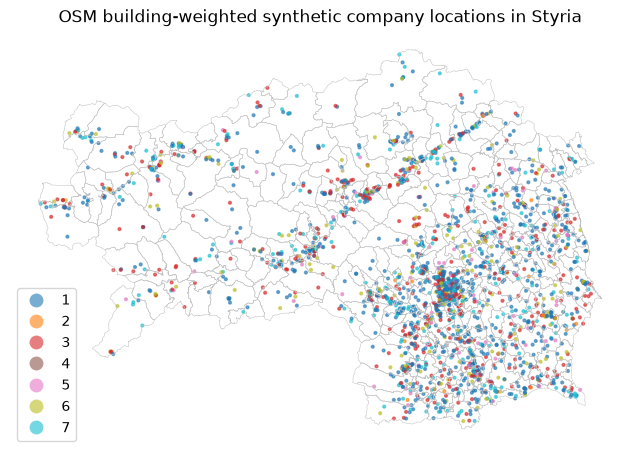

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
municipalities.boundary.plot(ax=ax, color="0.75", linewidth=0.35)
companies_syn.sample(min(2_000, len(companies_syn)), random_state=RANDOM_SEED).plot(
    ax=ax,
    column="Sparte_ID",
    categorical=True,
    cmap="tab10",
    markersize=4,
    alpha=0.6,
    legend=True,
)
ax.set_title("OSM building-weighted synthetic company locations in Styria")
ax.set_axis_off()
plt.show()


## Export

GeoParquet preserves the point geometry, CRS, column types, and missing date values. It is preferable to CSV for this dataset.


In [7]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
companies_syn.to_parquet(OUTPUT_PATH, index=False)
print(f"Saved synthetic data to: {OUTPUT_PATH}")


Saved synthetic data to: c:\Users\leopo\Documents\CO2_Master_Code\CO2_Masterarbeit\SDG\companies_styria_syn.geoparquet
